# Assignment 5: Classification Showdown - SOLUTION

Build and compare classification models on the Fashion-MNIST dataset.

## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from xgboost import XGBClassifier

from helpers import load_fashion_mnist, plot_roc_curves, plot_confusion_matrix

# Create output directory
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete!")

Setup complete!


---

## Part 1: Binary Classification

**Task:** Classify T-shirts (label 0) vs Trousers (label 1)

In [2]:
print("Part 1: Binary Classification")
print("-" * 40)

# Load the full dataset
X, y = load_fashion_mnist()

# Filter to only labels 0 and 1
mask = np.isin(y, [0, 1])
X_filtered = X[mask]
y_filtered = y[mask]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

# Scale features - fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Save results
results = {
    "task": "tshirt_vs_trouser",
    "accuracy": accuracy,
    "confusion_matrix": cm.tolist()
}
with open(os.path.join(OUTPUT_DIR, "part1_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"Accuracy: {accuracy:.4f}")
print(f"Confusion Matrix:\n{cm}")

Part 1: Binary Classification
----------------------------------------


Accuracy: 0.9836
Confusion Matrix:
[[1371   29]
 [  17 1383]]


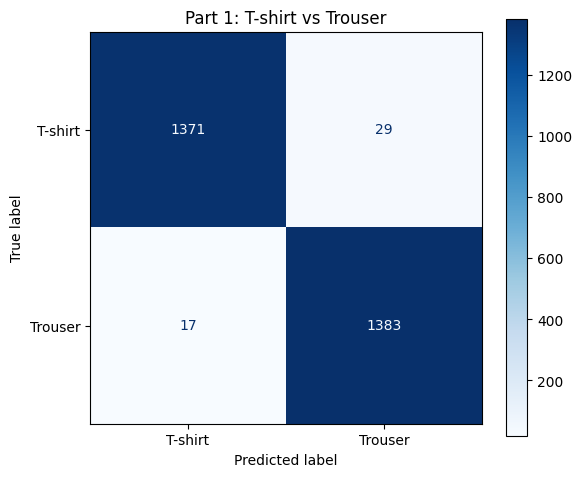

In [3]:
# Visualize results
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T-shirt', 'Trouser']).plot(ax=ax, cmap='Blues')
ax.set_title('Part 1: T-shirt vs Trouser')
plt.tight_layout()
plt.show()

---

## Part 2: Multi-class Classification with Cross-Validation

**Task:** Classify footwear types: Sandal (5) vs Sneaker (7) vs Ankle boot (9)

In [4]:
print("\nPart 2: Multi-class Classification with CV")
print("-" * 40)

# Load data, filter to labels 5, 7, 9
X, y = load_fashion_mnist()
mask = np.isin(y, [5, 7, 9])
X_filtered = X[mask]
y_filtered = y[mask]

# Encode labels to 0, 1, 2 (required for XGBoost)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_filtered)

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to compare
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

# Run 5-fold CV for each model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    for fold, score in enumerate(scores, 1):
        cv_results.append({'model': name, 'fold': fold, 'score': score})
    print(f"{name}: mean CV accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Save CV results
cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(os.path.join(OUTPUT_DIR, "part2_cv_results.csv"), index=False)

# Find best model by mean CV score
mean_scores = cv_df.groupby('model')['score'].mean()
best_model_name = mean_scores.idxmax()
print(f"\nBest model: {best_model_name} (mean CV accuracy: {mean_scores[best_model_name]:.4f})")

# Retrain best model on full training data
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred = best_model.predict(X_test_scaled)
report = classification_report(y_test, y_pred, output_dict=True)
print(f"\nTest set classification report:\n{classification_report(y_test, y_pred)}")

# Save test results
test_df = pd.DataFrame(report).transpose()
test_df.to_csv(os.path.join(OUTPUT_DIR, "part2_test_results.csv"))


Part 2: Multi-class Classification with CV
----------------------------------------


LogisticRegression: mean CV accuracy = 0.9276 (+/- 0.0126)


RandomForest: mean CV accuracy = 0.9524 (+/- 0.0077)


XGBoost: mean CV accuracy = 0.9670 (+/- 0.0066)

Best model: XGBoost (mean CV accuracy: 0.9670)



Test set classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1400
           1       0.95      0.97      0.96      1400
           2       0.97      0.96      0.97      1400

    accuracy                           0.97      4200
   macro avg       0.97      0.97      0.97      4200
weighted avg       0.97      0.97      0.97      4200



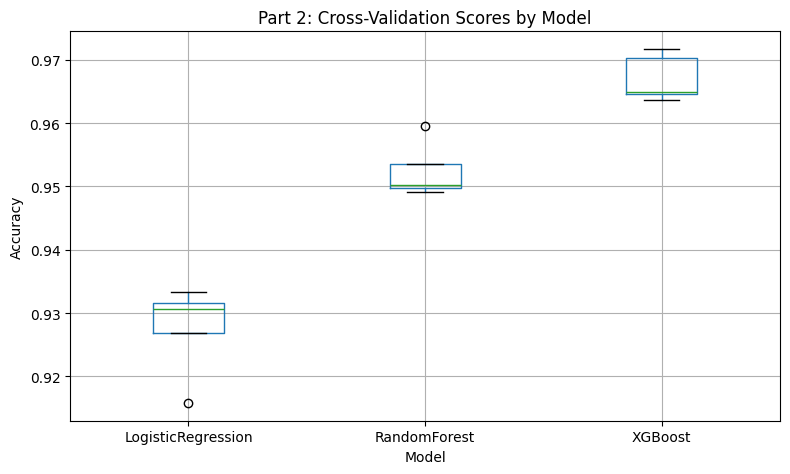

In [5]:
# Visualize CV results
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
cv_df.boxplot(column='score', by='model', ax=ax)
ax.set_title('Part 2: Cross-Validation Scores by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
plt.suptitle('')
plt.tight_layout()
plt.show()

---

## Part 3: Full Model Comparison Pipeline

**Task:** Classify Clothing vs Footwear (binary)

- **Clothing (0):** T-shirt, Trouser, Pullover, Dress, Coat, Shirt (labels 0-4, 6)
- **Footwear (1):** Sandal, Sneaker, Ankle boot (labels 5, 7, 9)
- **Exclude:** Bag (label 8)

In [6]:
print("\nPart 3: Full Model Comparison Pipeline")
print("-" * 40)

# Load data, filter out bags (label 8)
X, y = load_fashion_mnist()
mask = y != 8
X_filtered = X[mask]
y_original = y[mask]

# Create binary labels: footwear (5, 7, 9) = 1, clothing = 0
y_binary = np.isin(y_original, [5, 7, 9]).astype(int)

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to compare
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

# Run 5-fold CV for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    for fold, score in enumerate(scores, 1):
        cv_results.append({'model': name, 'fold': fold, 'auc': score})
    print(f"{name}: mean CV AUC = {scores.mean():.4f}")

# Save CV results
cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(os.path.join(OUTPUT_DIR, "part3_cv_results.csv"), index=False)

# Find best model by mean AUC
mean_aucs = cv_df.groupby('model')['auc'].mean()
best_model_name = mean_aucs.idxmax()
print(f"\nBest model: {best_model_name} (mean CV AUC: {mean_aucs[best_model_name]:.4f})")

# Train ALL models on full training data (needed for ROC curves)
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

# Generate ROC curves
plot_roc_curves(trained_models, X_test_scaled, y_test,
                os.path.join(OUTPUT_DIR, "part3_roc_curves.png"))
print("ROC curves saved to output/part3_roc_curves.png")

# Evaluate best model on test set
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
test_accuracy = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

# Generate confusion matrix for best model
plot_confusion_matrix(y_test, y_pred, ['Clothing', 'Footwear'],
                      os.path.join(OUTPUT_DIR, "part3_confusion_matrix.png"))
print("Confusion matrix saved to output/part3_confusion_matrix.png")

# Save test results
test_results = pd.DataFrame([{
    'model': best_model_name,
    'accuracy': test_accuracy,
    'auc': test_auc
}])
test_results.to_csv(os.path.join(OUTPUT_DIR, "part3_test_results.csv"), index=False)

print(f"\nFinal Results:")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  Test AUC: {test_auc:.4f}")


Part 3: Full Model Comparison Pipeline
----------------------------------------


LogisticRegression: mean CV AUC = 0.9997


RandomForest: mean CV AUC = 1.0000


XGBoost: mean CV AUC = 1.0000

Best model: XGBoost (mean CV AUC: 1.0000)


ROC curves saved to output/part3_roc_curves.png


Confusion matrix saved to output/part3_confusion_matrix.png

Final Results:
  Test Accuracy: 0.9994
  Test AUC: 1.0000


ROC Curves:


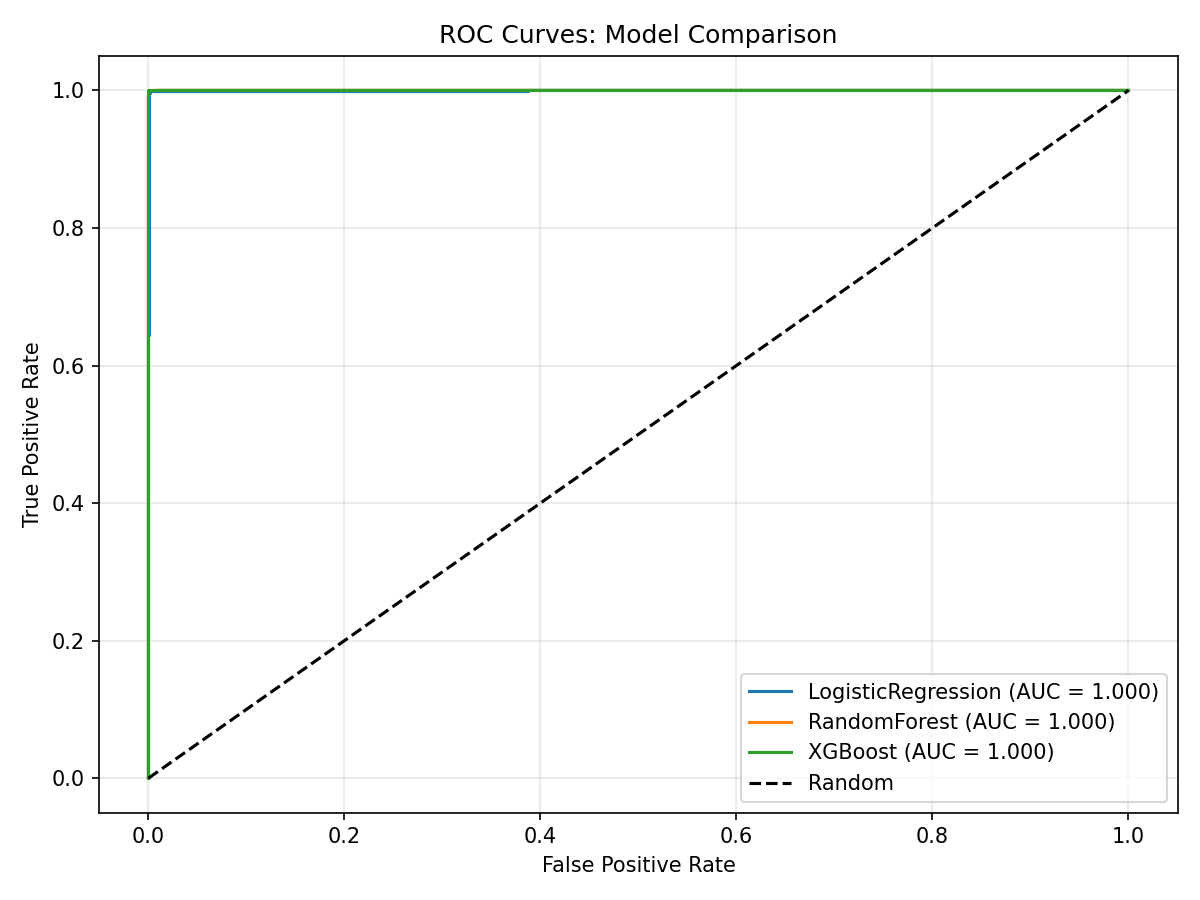


Confusion Matrix:


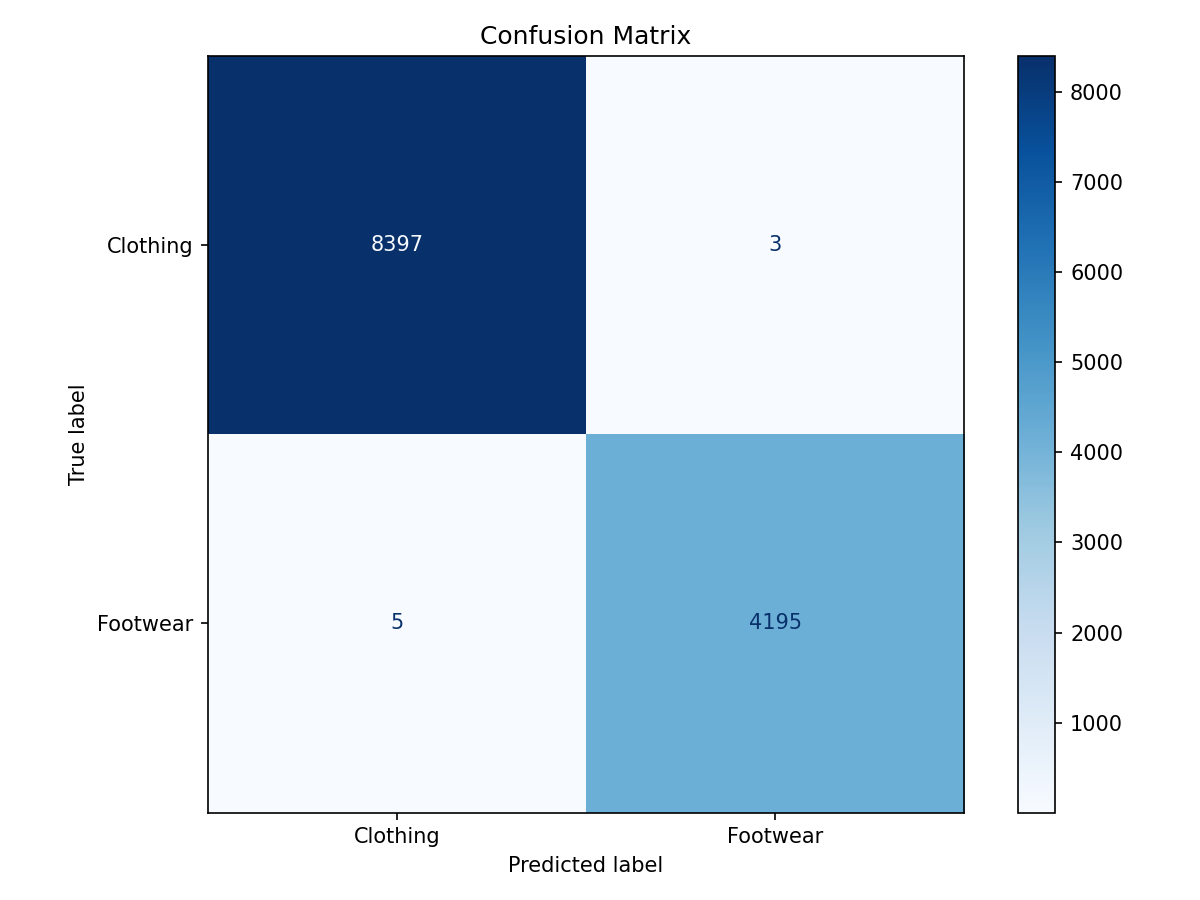

In [7]:
# Display the saved plots
from IPython.display import Image, display

print("ROC Curves:")
display(Image(filename=os.path.join(OUTPUT_DIR, "part3_roc_curves.png")))

print("\nConfusion Matrix:")
display(Image(filename=os.path.join(OUTPUT_DIR, "part3_confusion_matrix.png")))

---

## Validation

In [8]:
# Run in terminal: pytest .github/tests/ -v
print("Run 'pytest .github/tests/ -v' in your terminal to check your work.")

Run 'pytest .github/tests/ -v' in your terminal to check your work.
